In [1]:
import matplotlib.pyplot as plt
import streamlit as st
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from os import system
from graphviz import Source
from sklearn import tree

In [2]:
def draw_meshgrid():
    a = np.arange(start=X[:, 0].min() - 1, stop=X[:, 0].max() + 1, step=0.01)
    b = np.arange(start=X[:, 1].min() - 1, stop=X[:, 1].max() + 1, step=0.01)

    XX, YY = np.meshgrid(a, b)

    input_array = np.array([XX.ravel(), YY.ravel()]).T

    return XX, YY, input_array

In [3]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

plt.style.use('fivethirtyeight')

In [4]:
st.sidebar.markdown("# Decision Tree Classifier")

criterion = st.sidebar.selectbox(
    'Criterion',
    ('gini', 'entropy')
)

splitter = st.sidebar.selectbox(
    'Splitter',
    ('best', 'random')
)

2024-05-11 12:30:39.050 
  command:

    streamlit run C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


In [5]:
max_depth = int(st.sidebar.number_input('Max Depth'))

min_samples_split = st.sidebar.slider('Min Samples Split', 1, X_train.shape[0], 2,key=1234)

min_samples_leaf = st.sidebar.slider('Min Samples Leaf', 1, X_train.shape[0], 1,key=1235)

max_features = st.sidebar.slider('Max Features', 1, 2, 2,key=1236)

max_leaf_nodes = int(st.sidebar.number_input('Max Leaf Nodes'))

min_impurity_decrease = st.sidebar.number_input('Min Impurity Decrease')

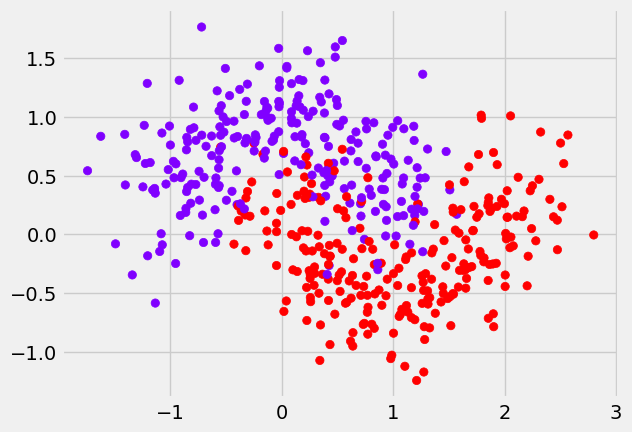

In [6]:
# Load initial graph
fig, ax = plt.subplots()

# Plot initial graph
ax.scatter(X.T[0], X.T[1], c=y, cmap='rainbow')
orig = st.pyplot(fig)

if st.sidebar.button('Run Algorithm'):

    orig.empty()

    if max_depth == 0:
        max_depth = None

    if max_leaf_nodes == 0:
        max_leaf_nodes = None

    clf = DecisionTreeClassifier(criterion=criterion,splitter=splitter,max_depth=max_depth,random_state=42,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,max_features=max_features,max_leaf_nodes=max_leaf_nodes,min_impurity_decrease=min_impurity_decrease)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    XX, YY, input_array = draw_meshgrid()
    labels = clf.predict(input_array)

    ax.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5, cmap='rainbow')
    plt.xlabel("Col1")
    plt.ylabel("Col2")
    orig = st.pyplot(fig)
    st.subheader("Accuracy for Decision Tree  " + str(round(accuracy_score(y_test, y_pred), 2)))

    tree = export_graphviz(clf,feature_names=["Col1","Col2"])

    st.graphviz_chart(tree)